In [12]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.messages import RemoveMessage

In [13]:
load_dotenv()

True

In [14]:
model = ChatOpenAI()

In [15]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [16]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [17]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [18]:
graph = builder.compile(checkpointer=InMemorySaver())

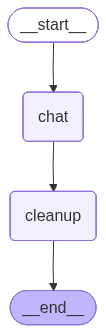

In [19]:
graph

In [20]:
config = {"configurable": {"thread_id": "t1"}}

In [21]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Ritik"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='4988eb1c-2bff-4319-b8e9-1cc40d365130'),
  AIMessage(content='LangChain is a blockchain-based platform designed to facilitate decentralized AI development and deployment. It aims to provide a secure and transparent infrastructure for AI projects, allowing developers to collaborate, share resources, and monetize their work. LangChain leverages blockchain technology to create a trustless environment for AI innovation, with features such as smart contracts, data privacy protection, and token incentives. By combining AI and blockchain, LangChain seeks to address key challenges in the AI industry, such as data privacy, model ownership, and accountability.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 250, 'total_tokens': 353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_to

In [22]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
